In [ ]:
# Install necessary packages
!pip install -q tensorflow numpy

# Imports
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Load the saved Turtle_Net-B4 model
model = tf.keras.models.load_model('/content/drive/MyDrive/Turtle_Net-B4.h5', compile=False)

# Prepare the test set
test_dir = '/content/drive/MyDrive/Dataset/Testing'

datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(380, 380),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Predict on the test set
y_probs = model.predict(test_generator)
y_pred = np.argmax(y_probs, axis=1)
y_true = test_generator.classes

# Save the predictions
save_dir = '/content/drive/MyDrive/Turtle_Net_B4_results'
import os
os.makedirs(save_dir, exist_ok=True)

np.save(f'{save_dir}/y_true.npy', y_true)
np.save(f'{save_dir}/y_pred.npy', y_pred)
np.save(f'{save_dir}/y_probs.npy', y_probs)

print(f"Predictions saved to {save_dir}")


Mounted at /content/drive
Found 291 images belonging to 6 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


10/10 ━━━━━━━━━━━━━━━━━━━━ 111s 10s/step
Predictions saved to /content/drive/MyDrive/Turtle_Net_B4_results



✅ Loaded predictions from YOLOv8 and Turtle_Net-B4 for 291 samples.

🔵 HARD VOTING
Hard Voting Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1-Score: 100.00%


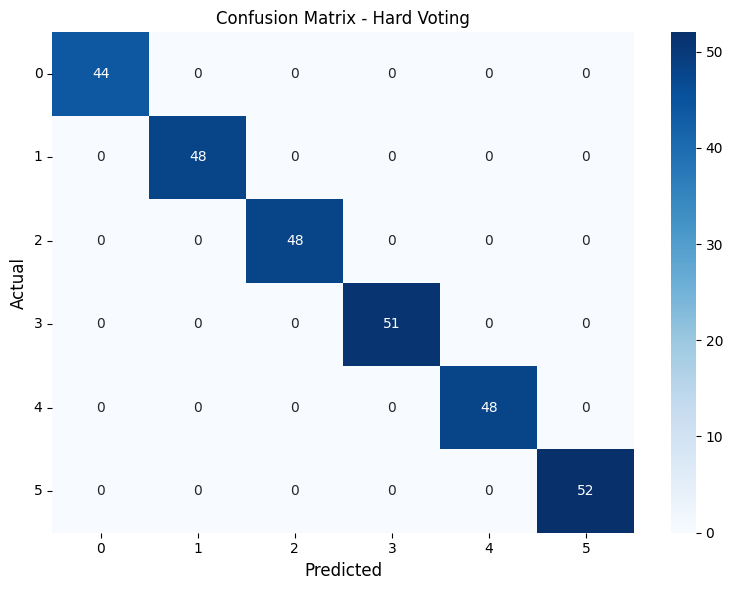


🟢 SOFT VOTING
Soft Voting Accuracy: 99.66%
Precision: 99.66%
Recall: 99.66%
F1-Score: 99.66%


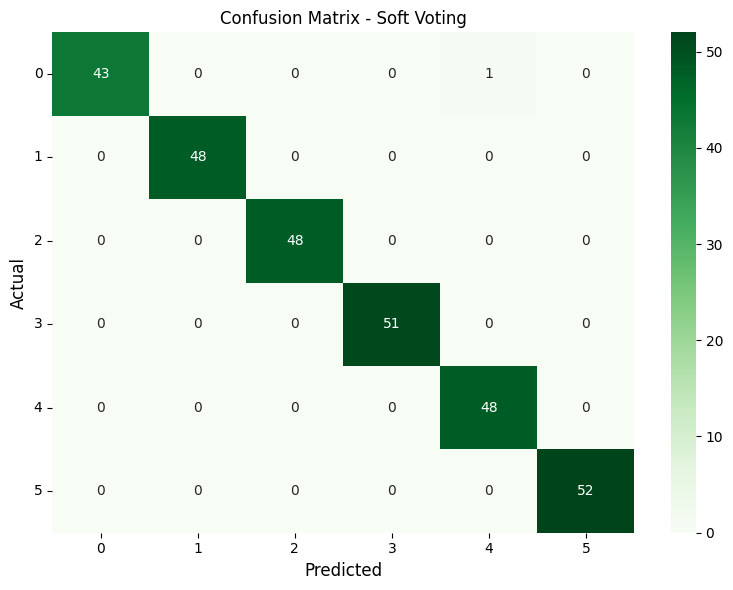


📝 Classification Report (Soft Voting):
                      precision    recall  f1-score   support

  Amyda cartilaginea       1.00      0.98      0.99        44
     Cuora boinensis       1.00      1.00      1.00        48
    Cyclemys dentata       1.00      1.00      1.00        48
Melanochelys trijuga       1.00      1.00      1.00        51
 Nilssonia gangetica       0.98      1.00      0.99        48
  Pangshura tentoria       1.00      1.00      1.00        52

            accuracy                           1.00       291
           macro avg       1.00      1.00      1.00       291
        weighted avg       1.00      1.00      1.00       291



In [ ]:
# Install required libraries
!pip install -q scikit-learn numpy seaborn matplotlib

# Import libraries
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os

# === Load Saved Predictions ===
# YOLOv8 results path
yolo_dir = '/content/drive/MyDrive/yolo_results_folder'  # <-- update if different

# Turtle_Net-B4 results path
turtle_net_dir = '/content/drive/MyDrive/Turtle_Net_B4_results'

# Load YOLOv8 predictions
y_true_yolo = np.load(os.path.join(yolo_dir, 'y_true.npy'))
y_pred_yolo = np.load(os.path.join(yolo_dir, 'y_pred.npy'))
y_probs_yolo = np.load(os.path.join(yolo_dir, 'y_probs.npy'))

# Load Turtle_Net-B4 predictions
y_true_turtle = np.load(os.path.join(turtle_net_dir, 'y_true.npy'))
y_pred_turtle = np.load(os.path.join(turtle_net_dir, 'y_pred.npy'))
y_probs_turtle = np.load(os.path.join(turtle_net_dir, 'y_probs.npy'))

# Check that y_true matches
assert np.array_equal(y_true_yolo, y_true_turtle), "Mismatch between y_true arrays!"
y_true = y_true_yolo

print(f"\n✅ Loaded predictions from YOLOv8 and Turtle_Net-B4 for {len(y_true)} samples.\n")

# === HARD VOTING ===
print("🔵 HARD VOTING")
hard_preds = []

for i in range(len(y_true)):
    votes = [y_pred_yolo[i], y_pred_turtle[i]]
    final_vote = max(set(votes), key=votes.count)
    hard_preds.append(final_vote)

hard_preds = np.array(hard_preds)

# Metrics for Hard Voting
hard_acc = accuracy_score(y_true, hard_preds)
hard_prec = precision_score(y_true, hard_preds, average='weighted')
hard_rec = recall_score(y_true, hard_preds, average='weighted')
hard_f1 = f1_score(y_true, hard_preds, average='weighted')

print(f"Hard Voting Accuracy: {hard_acc*100:.2f}%")
print(f"Precision: {hard_prec*100:.2f}%")
print(f"Recall: {hard_rec*100:.2f}%")
print(f"F1-Score: {hard_f1*100:.2f}%")

# === CONFUSION MATRIX for Hard Voting ===
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, hard_preds),
            annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Hard Voting')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# === SOFT VOTING ===
print("\n🟢 SOFT VOTING")
avg_probs = (y_probs_yolo + y_probs_turtle) / 2.0
soft_preds = np.argmax(avg_probs, axis=1)

# Metrics for Soft Voting
soft_acc = accuracy_score(y_true, soft_preds)
soft_prec = precision_score(y_true, soft_preds, average='weighted')
soft_rec = recall_score(y_true, soft_preds, average='weighted')
soft_f1 = f1_score(y_true, soft_preds, average='weighted')

print(f"Soft Voting Accuracy: {soft_acc*100:.2f}%")
print(f"Precision: {soft_prec*100:.2f}%")
print(f"Recall: {soft_rec*100:.2f}%")
print(f"F1-Score: {soft_f1*100:.2f}%")

# === CONFUSION MATRIX for Soft Voting ===
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, soft_preds),
            annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Soft Voting')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# === CLASSIFICATION REPORT ===
print("\n📝 Classification Report (Soft Voting):")
# Define your actual class names
class_names = [
    'Amyda cartilaginea',
    'Cuora boinensis',
    'Cyclemys dentata',
    'Melanochelys trijuga',
    'Nilssonia gangetica',
    'Pangshura tentoria'
]
print(classification_report(y_true, soft_preds, target_names=class_names))
